## Cleaning

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score
import re
from collections import Counter



jeopardy = pd.read_csv('JEOPARDY_CSV.csv') 

jeopardy

,Show Number,Air Date,Round,Category,Value,Question,Answer
0,4680,2004-12-31,Jeopardy!,HISTORY,$200,"For the last 8 years of his life, Galileo was ...",Copernicus
1,4680,2004-12-31,Jeopardy!,ESPN's TOP 10 ALL-TIME ATHLETES,$200,No. 2: 1912 Olympian; football star at Carlisl...,Jim Thorpe
2,4680,2004-12-31,Jeopardy!,EVERYBODY TALKS ABOUT IT...,$200,The city of Yuma in this state has a record av...,Arizona
3,4680,2004-12-31,Jeopardy!,THE COMPANY LINE,$200,"In 1963, live on ""The Art Linkletter Show"", th...",McDonald's
4,4680,2004-12-31,Jeopardy!,EPITAPHS & TRIBUTES,$200,"Signer of the Dec. of Indep., framer of the Co...",John Adams
...,...,...,...,...,...,...,...
216925,4999,2006-05-11,Double Jeopardy!,RIDDLE ME THIS,$2000,This Puccini opera turns on the solution to 3 ...,Turandot
216926,4999,2006-05-11,Double Jeopardy!,"""T"" BIRDS",$2000,In North America this term is properly applied...,a titmouse
216927,4999,2006-05-11,Double Jeopardy!,AUTHORS IN THEIR YOUTH,$2000,"In Penny Lane, where this ""Hellraiser"" grew up...",Clive Barker
216928,4999,2006-05-11,Double Jeopardy!,QUOTATIONS,$2000,"From Ft. Sill, Okla. he made the plea, Arizona...",Geronimo


In [3]:
jeopardy_data = jeopardy.copy()

jeopardy.columns = jeopardy.columns.str.strip()

jeopardy_data['Value'] = jeopardy_data['Value'].replace(r'[\$,]', '', regex=True).astype(float)
jeopardy_data['Value'] = jeopardy_data['Value'].fillna(0)

# Step 2: Remove HTML tags from the 'Question' column
jeopardy_data['Question'] = jeopardy_data['Question'].str.replace(r'<.*?>', '', regex=True)

# Step 3: Filter and clean the dataset
jeopardy_adjusted_data = jeopardy_data[
    (jeopardy_data['Value'] != 0) & (~jeopardy_data['Value'].isna())
]




In [4]:
import pandas as pd

# Ensure 'Air Date' is in datetime format
jeopardy_adjusted_data['Air Date'] = pd.to_datetime(jeopardy_adjusted_data['Air Date'])

# Apply the transformation
jeopardy_adjusted_data['Value'] = jeopardy_adjusted_data.apply(
    lambda row: row['Value'] * 2 if row['Air Date'] < pd.Timestamp('2001-11-26') else row['Value'], 
    axis=1
)



C:\Users\rohit\AppData\Local\Temp\ipykernel_13284\1423083528.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jeopardy_adjusted_data['Air Date'] = pd.to_datetime(jeopardy_adjusted_data['Air Date'])
C:\Users\rohit\AppData\Local\Temp\ipykernel_13284\1423083528.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jeopardy_adjusted_data['Value'] = jeopardy_adjusted_data.apply(


## Modeling

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Tokenize the 'Question' column and remove stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
import os



In [32]:
jeopardy_adjusted_data['Combined_Text'] = (
    jeopardy_adjusted_data['Question'] + " " +
    jeopardy_adjusted_data['Answer'] + " " +
    jeopardy_adjusted_data['Round']
)


print(jeopardy_adjusted_data[['Combined_Text']].head())

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


import nltk
nltk.download('stopwords')
nltk.download('punkt')


stop_words = set(stopwords.words('english'))

# Define the cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return '' 
    tokens = word_tokenize(text.lower())  
    return ' '.join([word for word in tokens if word.isalpha() and word not in stop_words])

# Ensure 'Combined_Text' contains only strings
jeopardy_adjusted_data['Combined_Text'] = jeopardy_adjusted_data['Combined_Text'].fillna('').astype(str)

# Apply the cleaning function to the 'Combined_Text' column
jeopardy_adjusted_data['cleaned_combined_text'] = jeopardy_adjusted_data['Combined_Text'].apply(clean_text)

# Example check
print(jeopardy_adjusted_data[['Combined_Text', 'cleaned_combined_text']].head())



                                       Combined_Text
0  For the last 8 years of his life, Galileo was ...
1  No. 2: 1912 Olympian; football star at Carlisl...
2  The city of Yuma in this state has a record av...
3  In 1963, live on "The Art Linkletter Show", th...
4  Signer of the Dec. of Indep., framer of the Co...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rohit/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\rohit/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                       Combined_Text  \
0  For the last 8 years of his life, Galileo was ...   
1  No. 2: 1912 Olympian; football star at Carlisl...   
2  The city of Yuma in this state has a record av...   
3  In 1963, live on "The Art Linkletter Show", th...   
4  Signer of the Dec. of Indep., framer of the Co...   

                               cleaned_combined_text  
0  last years life galileo house arrest espousing...  
1  olympian football star carlisle indian school ...  
2  city yuma state record average hours sunshine ...  
3  live art linkletter show company served billio...  
4  signer framer constitution second president un...  


In [33]:

value_counts = jeopardy_adjusted_data['Value'].value_counts()


valid_values = value_counts[value_counts >= 1000].index


jeopardy_adjusted_data = jeopardy_adjusted_data[jeopardy_adjusted_data['Value'].isin(valid_values)]


jeopardy_adjusted_data['Value'].value_counts()


# Split into Jeopardy and Double Jeopardy datasets



Jeopardy dataset size: (106425, 9)
Double Jeopardy dataset size: (101735, 9)


In [34]:
# For the jeopardy round
jeopardy_data = jeopardy_data[~jeopardy_data['Value'].isin([2000, 1600, 1200])]

# For the double jeopardy round
double_jeopardy_data = double_jeopardy_data[~double_jeopardy_data['Value'].isin([1000, 600, 200])]

# To confirm the filtering, you can print value counts
print("Filtered Jeopardy 'Value' counts:")
print(jeopardy_data['Value'].value_counts())

print("\nFiltered Double Jeopardy 'Value' counts:")
print(double_jeopardy_data['Value'].value_counts())




Filtered Jeopardy 'Value' counts:
Value
200.0     21683
400.0     21467
1000.0    21326
600.0     20794
800.0     20267
Name: count, dtype: int64

Filtered Double Jeopardy 'Value' counts:
Value
400.0     21466
800.0     20834
2000.0    20731
1200.0    19503
1600.0    18600
Name: count, dtype: int64


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# TF-IDF Vectorization for Jeopardy
tfidf_vectorizer_jeop = TfidfVectorizer(max_features=5000, stop_words='english')
X_jeopardy = tfidf_vectorizer_jeop.fit_transform(jeopardy_data['cleaned_combined_text'])

# TF-IDF Vectorization for Double Jeopardy
tfidf_vectorizer_dj = TfidfVectorizer(max_features=5000, stop_words='english')
X_double_jeopardy = tfidf_vectorizer_dj.fit_transform(double_jeopardy_data['cleaned_combined_text'])


NameError: name 'jeopardy_data' is not defined

In [36]:
from sklearn.preprocessing import LabelEncoder

# Encode 'Value' for Jeopardy
label_encoder_jeop = LabelEncoder()
y_jeopardy = label_encoder_jeop.fit_transform(jeopardy_data['Value'])

# Encode 'Value' for Double Jeopardy
label_encoder_dj = LabelEncoder()
y_double_jeopardy = label_encoder_dj.fit_transform(double_jeopardy_data['Value'])

In [37]:
# Split Jeopardy data
X_train_jeop, X_test_jeop, y_train_jeop, y_test_jeop = train_test_split(X_jeopardy, y_jeopardy, test_size=0.2, random_state=42)

# Split Double Jeopardy data
X_train_dj, X_test_dj, y_train_dj, y_test_dj = train_test_split(X_double_jeopardy, y_double_jeopardy, test_size=0.2, random_state=42)


In [38]:
# Train logistic regression on Jeopardy data
lr_jeop = LogisticRegression(max_iter=1000, random_state=42)
lr_jeop.fit(X_train_jeop, y_train_jeop)

# Train logistic regression on Double Jeopardy data
lr_dj = LogisticRegression(max_iter=1000, random_state=42)
lr_dj.fit(X_train_dj, y_train_dj)


LogisticRegression(max_iter=1000, random_state=42)

In [39]:
# Evaluate Jeopardy model
y_pred_jeop = lr_jeop.predict(X_test_jeop)
print("Jeopardy Classification Report:")
print(classification_report(y_test_jeop, y_pred_jeop, target_names=label_encoder_jeop.classes_.astype(str)))
print("Jeopardy Accuracy:", accuracy_score(y_test_jeop, y_pred_jeop))

# Evaluate Double Jeopardy model
y_pred_dj = lr_dj.predict(X_test_dj)
print("\nDouble Jeopardy Classification Report:")
print(classification_report(y_test_dj, y_pred_dj, target_names=label_encoder_dj.classes_.astype(str)))
print("Double Jeopardy Accuracy:", accuracy_score(y_test_dj, y_pred_dj))


Jeopardy Classification Report:
              precision    recall  f1-score   support

       200.0       0.25      0.29      0.27      4305
       400.0       0.21      0.20      0.20      4360
       600.0       0.20      0.18      0.19      4138
       800.0       0.19      0.17      0.18      4017
      1000.0       0.24      0.27      0.26      4288

    accuracy                           0.22     21108
   macro avg       0.22      0.22      0.22     21108
weighted avg       0.22      0.22      0.22     21108

Jeopardy Accuracy: 0.22152738298275534

Double Jeopardy Classification Report:
              precision    recall  f1-score   support

       400.0       0.27      0.33      0.30      4361
       800.0       0.21      0.21      0.21      4131
      1200.0       0.19      0.16      0.17      3884
      1600.0       0.19      0.15      0.17      3748
      2000.0       0.26      0.30      0.28      4103

    accuracy                           0.23     20227
   macro avg       0

In [40]:
# Predict values for Jeopardy
jeopardy_pred_labels = lr_jeop.predict(X_test_jeop)

# Predict values for Double Jeopardy
double_jeopardy_pred_labels = lr_dj.predict(X_test_dj)


In [41]:
# Map predictions and true values back to original categories for Jeopardy
jeopardy_true_values = label_encoder_jeop.inverse_transform(y_test_jeop)
jeopardy_predicted_values = label_encoder_jeop.inverse_transform(jeopardy_pred_labels)

# Map predictions and true values back to original categories for Double Jeopardy
double_jeopardy_true_values = label_encoder_dj.inverse_transform(y_test_dj)
double_jeopardy_predicted_values = label_encoder_dj.inverse_transform(double_jeopardy_pred_labels)


In [42]:
import pandas as pd

# Jeopardy predictions DataFrame
jeopardy_results = pd.DataFrame({
    'True Value': jeopardy_true_values,
    'Predicted Value': jeopardy_predicted_values
})

# Double Jeopardy predictions DataFrame
double_jeopardy_results = pd.DataFrame({
    'True Value': double_jeopardy_true_values,
    'Predicted Value': double_jeopardy_predicted_values
})


In [44]:
# Preview Jeopardy predictions
print("Jeopardy Predictions:")
print(jeopardy_results.head())

# Preview Double Jeopardy predictions
print("\nDouble Jeopardy Predictions:")
print(double_jeopardy_results.head())


jeopardy_results

Jeopardy Predictions:
   True Value  Predicted Value
0       600.0            400.0
1       600.0            800.0
2       800.0            400.0
3      1000.0            400.0
4       400.0            800.0

Double Jeopardy Predictions:
   True Value  Predicted Value
0       400.0           1200.0
1       800.0           1200.0
2       400.0            400.0
3      2000.0            800.0
4       400.0            400.0


,True Value,Predicted Value
0,600.0,400.0
1,600.0,800.0
2,800.0,400.0
3,1000.0,400.0
4,400.0,800.0
...,...,...
21103,1000.0,1000.0
21104,400.0,800.0
21105,600.0,200.0
21106,400.0,600.0


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix for Jeopardy
jeopardy_cm = confusion_matrix(jeopardy_true_values, jeopardy_predicted_values)

# Generate confusion matrix for Double Jeopardy
double_jeopardy_cm = confusion_matrix(double_jeopardy_true_values, double_jeopardy_predicted_values)


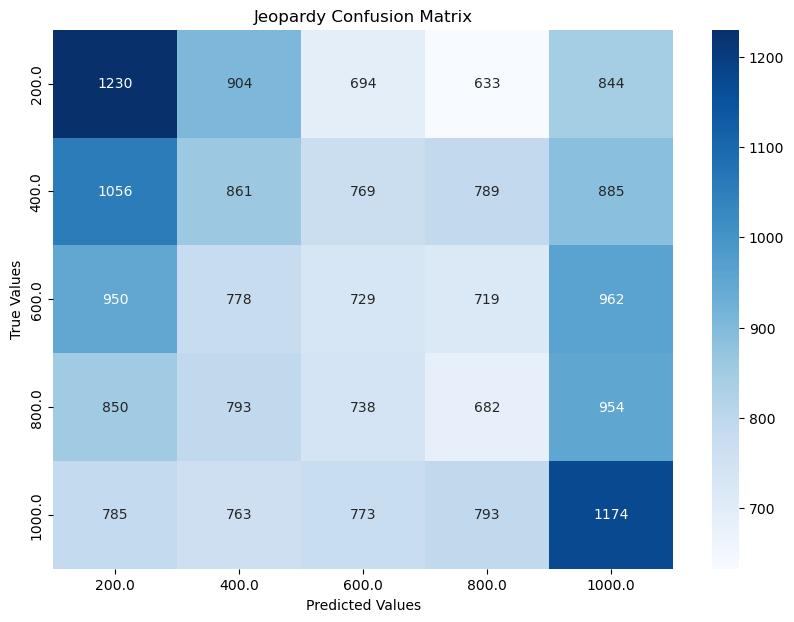

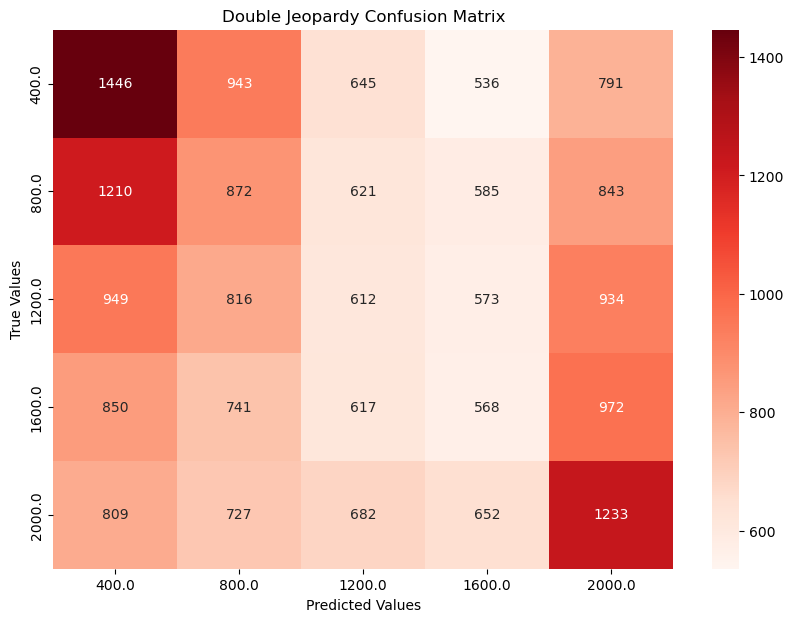

In [53]:
# Function to plot heatmap
def plot_confusion_matrix(cm, title, labels, color):
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Values')
    plt.ylabel('True Values')
    plt.show()

# Get the category labels for Jeopardy and Double Jeopardy
jeopardy_labels = label_encoder_jeop.classes_
double_jeopardy_labels = label_encoder_dj.classes_

# Plot Jeopardy confusion matrix
plot_confusion_matrix(jeopardy_cm, "Jeopardy Confusion Matrix", jeopardy_labels, 'Blues')

# Plot Double Jeopardy confusion matrix
plot_confusion_matrix(double_jeopardy_cm, "Double Jeopardy Confusion Matrix", double_jeopardy_labels, 'Reds')


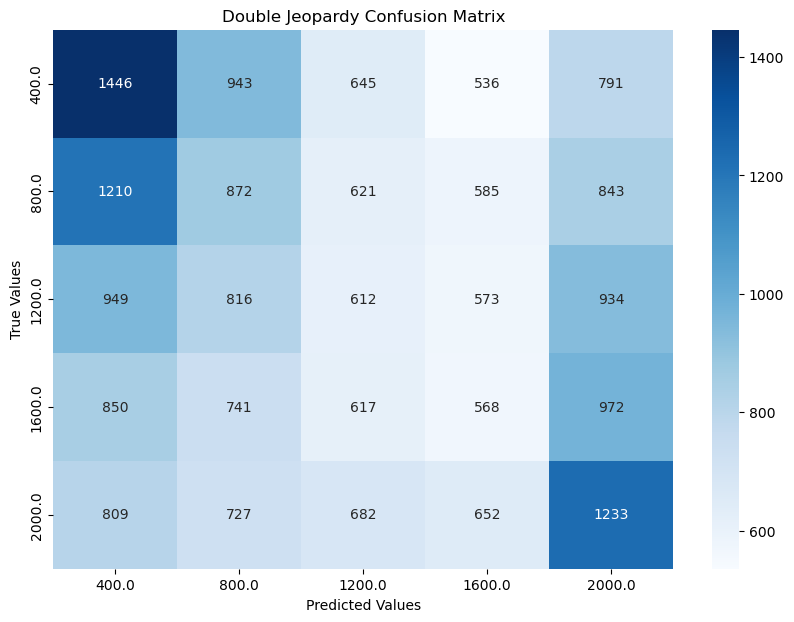